# Two-dimensional diffusion from Diracs to a Gaussian

This notebook generates `fig:generative-diffusion-2d-forward-backward`.  The data endpoint is a measure supported on three Dirac masses and the noising endpoint is a single centered Gaussian.  The forward interpolation
$$Z_t=(1-t)X+tY$$
turns the three atoms into a three-component Gaussian mixture which collapses to one Gaussian at $t=1$.


In [1]:
from pathlib import Path
import os
import sys
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")
for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from PIL import Image
import ot
from scipy.linalg import expm, solve
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter
from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, DIRAC_MARKER_SIZE,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, box_axes,
    interp_color, draw_point_clouds, draw_transport_segments, padded_limits,
)
setup_matplotlib()
rng = np.random.default_rng(2027)

In [2]:
NAME='generative-diffusion-2d-forward-backward'; out=figure_dir(NAME)
centers = np.array([[-1.02, -0.42], [1.02, -0.40], [0.00, 1.02]])
weights = np.ones(3) / 3
sigma = 0.24
xlim = (-1.48, 1.48)
ylim = (-0.90, 1.34)
gx = np.linspace(*xlim, 140)
gy = np.linspace(*ylim, 112)
X, Y = np.meshgrid(gx, gy)
G = np.c_[X.ravel(), Y.ravel()]

def forward_density(z, t):
    if t <= 1e-6:
        return np.zeros(len(z))
    means_t = (1 - t) * centers
    var = (t * sigma)**2
    diff = z[:, None, :] - means_t[None, :, :]
    dens = np.exp(-0.5 * np.sum(diff**2, axis=-1) / var) / (2*np.pi*var)
    return dens @ weights

fig, axes = plt.subplots(1, 5, figsize=(5.45, 1.22), gridspec_kw={'wspace': 0.015})
for ax, t in zip(axes, [0, .22, .45, .70, 1.0]):
    color = interp_color(float(t))
    if t <= 1e-6:
        ax.scatter(centers[:,0], centers[:,1], s=DIRAC_MARKER_SIZE*0.82, marker='o', color=RED, edgecolor='none', linewidth=0, zorder=3)
    else:
        den = forward_density(G, t).reshape(X.shape)
        den = den / max(den.max(), 1e-12)
        ax.contourf(X, Y, den, levels=np.linspace(.07, 1, 10), colors=[color], alpha=0.13)
        ax.contour(X, Y, den, levels=[.16, .32, .50, .70], colors=[color], linewidths=0.55, alpha=0.76)
        if t < .6:
            ax.scatter((1-t)*centers[:,0], (1-t)*centers[:,1], s=DIRAC_MARKER_SIZE*0.28, marker='o', color=color, edgecolor='none', linewidth=0, alpha=0.62, zorder=3)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal'); remove_axes(ax)
save_pdf(fig, out/'forward-density.pdf', pad_inches=0.018); plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


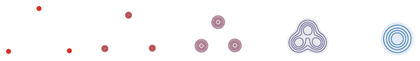

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/generative-diffusion-2d-forward-backward.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-diffusion-2d-forward-backward.png")
display(Image(filename=str(_thumb)))
